# Imports

In [1]:
import numpy as np 
import pandas as pd
from mggp import MGGP
import matplotlib.pyplot as plt
from utils.utils_hysteresis import *

E:\projetos\mggp_model\src\mggp\base.py:719: SyntaxWarning: invalid escape sequence '\d'
  if re.search("q\d", tree[i].name):


# Train Bouc-Wen model

In [7]:
# Filter requirements.
fs = 1000       # sample rate, Hz
cutoff = 1     # desired cutoff frequency of the filter, Hz ,      slightly higher than actual 1.2 Hz
nyq = 0.5 * fs  # Nyquist Frequency
order = 5      # sin wave can be approx represented as quadratic

t = np.arange(0,101,1/fs)
seed = 93862723
np.random.seed(seed)
dataX = np.random.normal(0, 450, size=(len(t)))
dataX[0:1000] = 0
dataX[-1000:] = 0
u = butter_lowpass_filter(dataX, cutoff, fs, order)
u = u.reshape(-1)
udot = np.diff(u)/np.diff(t)
udot = udot[999:]
u_train = u[1000:]
t = t[1000:]

y_train = simulate(u_train, udot)

u_test = 40*np.sin(2*np.pi*t)
udot = np.diff(u_test)/np.diff(t)
y_test = simulate(u_test, udot)

u_train = np.array([u_train]).T
y_train = np.array([y_train]).T
u_test = np.array([u_test]).T
y_test = np.array([y_test]).T

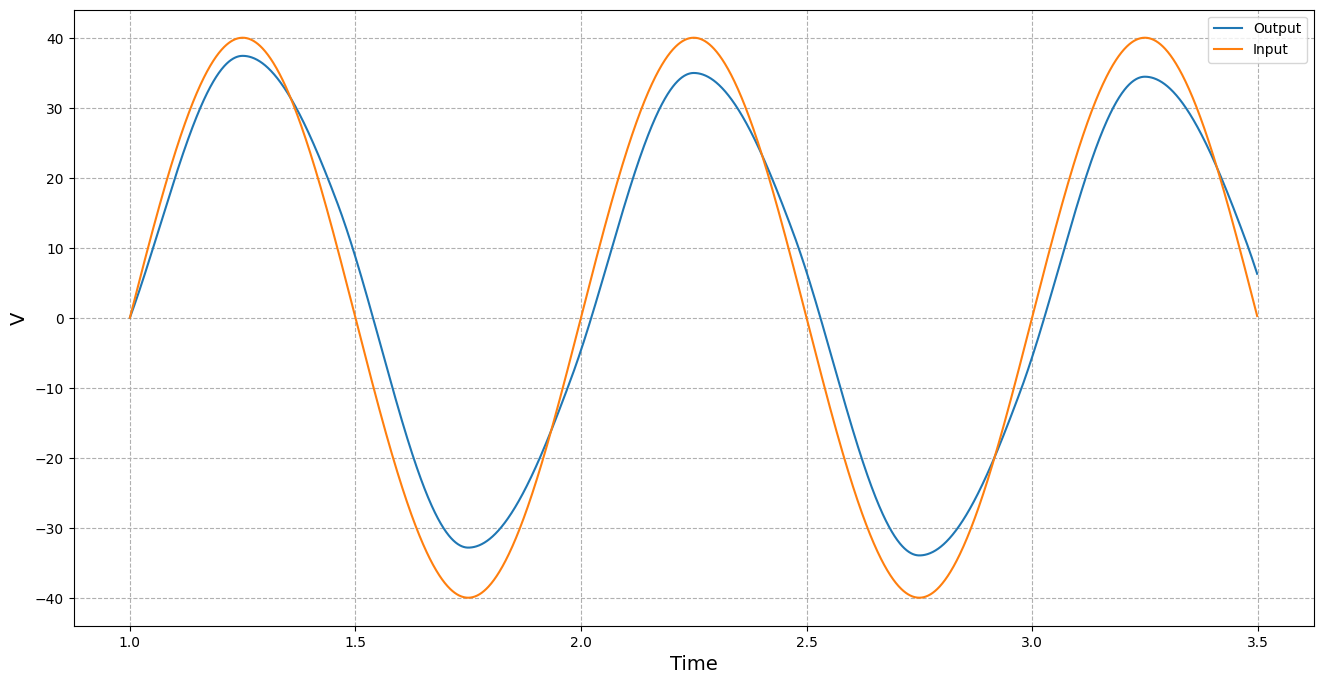

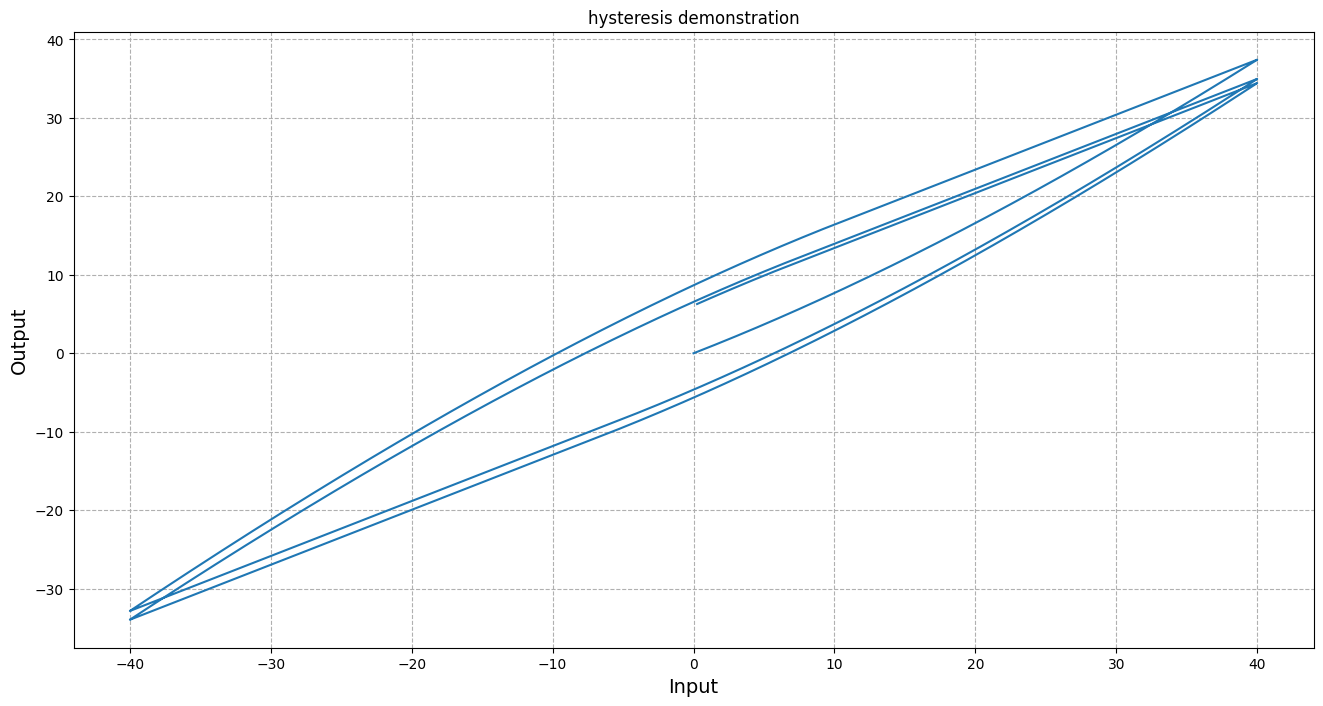

In [8]:
split = 2500
fontsize = 14
# time = data[1][:split]
plt.figure(figsize=(16, 8))
plt.plot(t[:split], y_test[:split], label='Output')
plt.plot(t[:split], u_test[:split], label='Input')
plt.grid(linestyle="--")
plt.xlabel("Time", fontsize=fontsize)
plt.ylabel("V", fontsize=fontsize)
plt.legend()
plt.show()


plt.figure(figsize=(16, 8))
plt.title("hysteresis demonstration")
# plt.plot(u_train[:split], y_train[:split])
plt.plot(u_test[:split], y_test[:split])
plt.grid(linestyle="--")
plt.xlabel("Input", fontsize=fontsize)
plt.ylabel("Output", fontsize=fontsize)
plt.show()

In [ ]:

# REMEMBER: Verify the set of subtration and sign functions in class Element (base.py)
mggp = MGGP(inputs=u_train,
            outputs=y_train,
            validation=(u_test, y_test),
            nDelays=[1, 2, 3, 4, 5],
            generations=250,
            populationSize=250,
            evaluationMode="RMSE",
            k=500,
            froe_mode=True,
            evaluationType='MShooting',
            evaluationTypeTest="FreeRun",
            nTerms=10,
            maxHeight=5,
            mutationRate=0.2,
            crossoverRate=0.8,
            pruning_probability=0.5,
            pruning_tolerance= 1e-5, 
            elitePercentage=10,
            filename = "mggp_models_hysteresis/mggp_0.pkl",
            mode="NARX",
            operators=['mul', 'sign', 'subtraction']
            )

mggp.run()

System Mode: SISO. N° Inputs: 1. N° Outputs: 1
Input Samples: 100000. Output Samples: 100000



Evaluating Initial Population:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluating Initial Population:   6%|▌         | 15/250 [00:03<00:47,  4.99it/s]

## Load and Evaluate Model

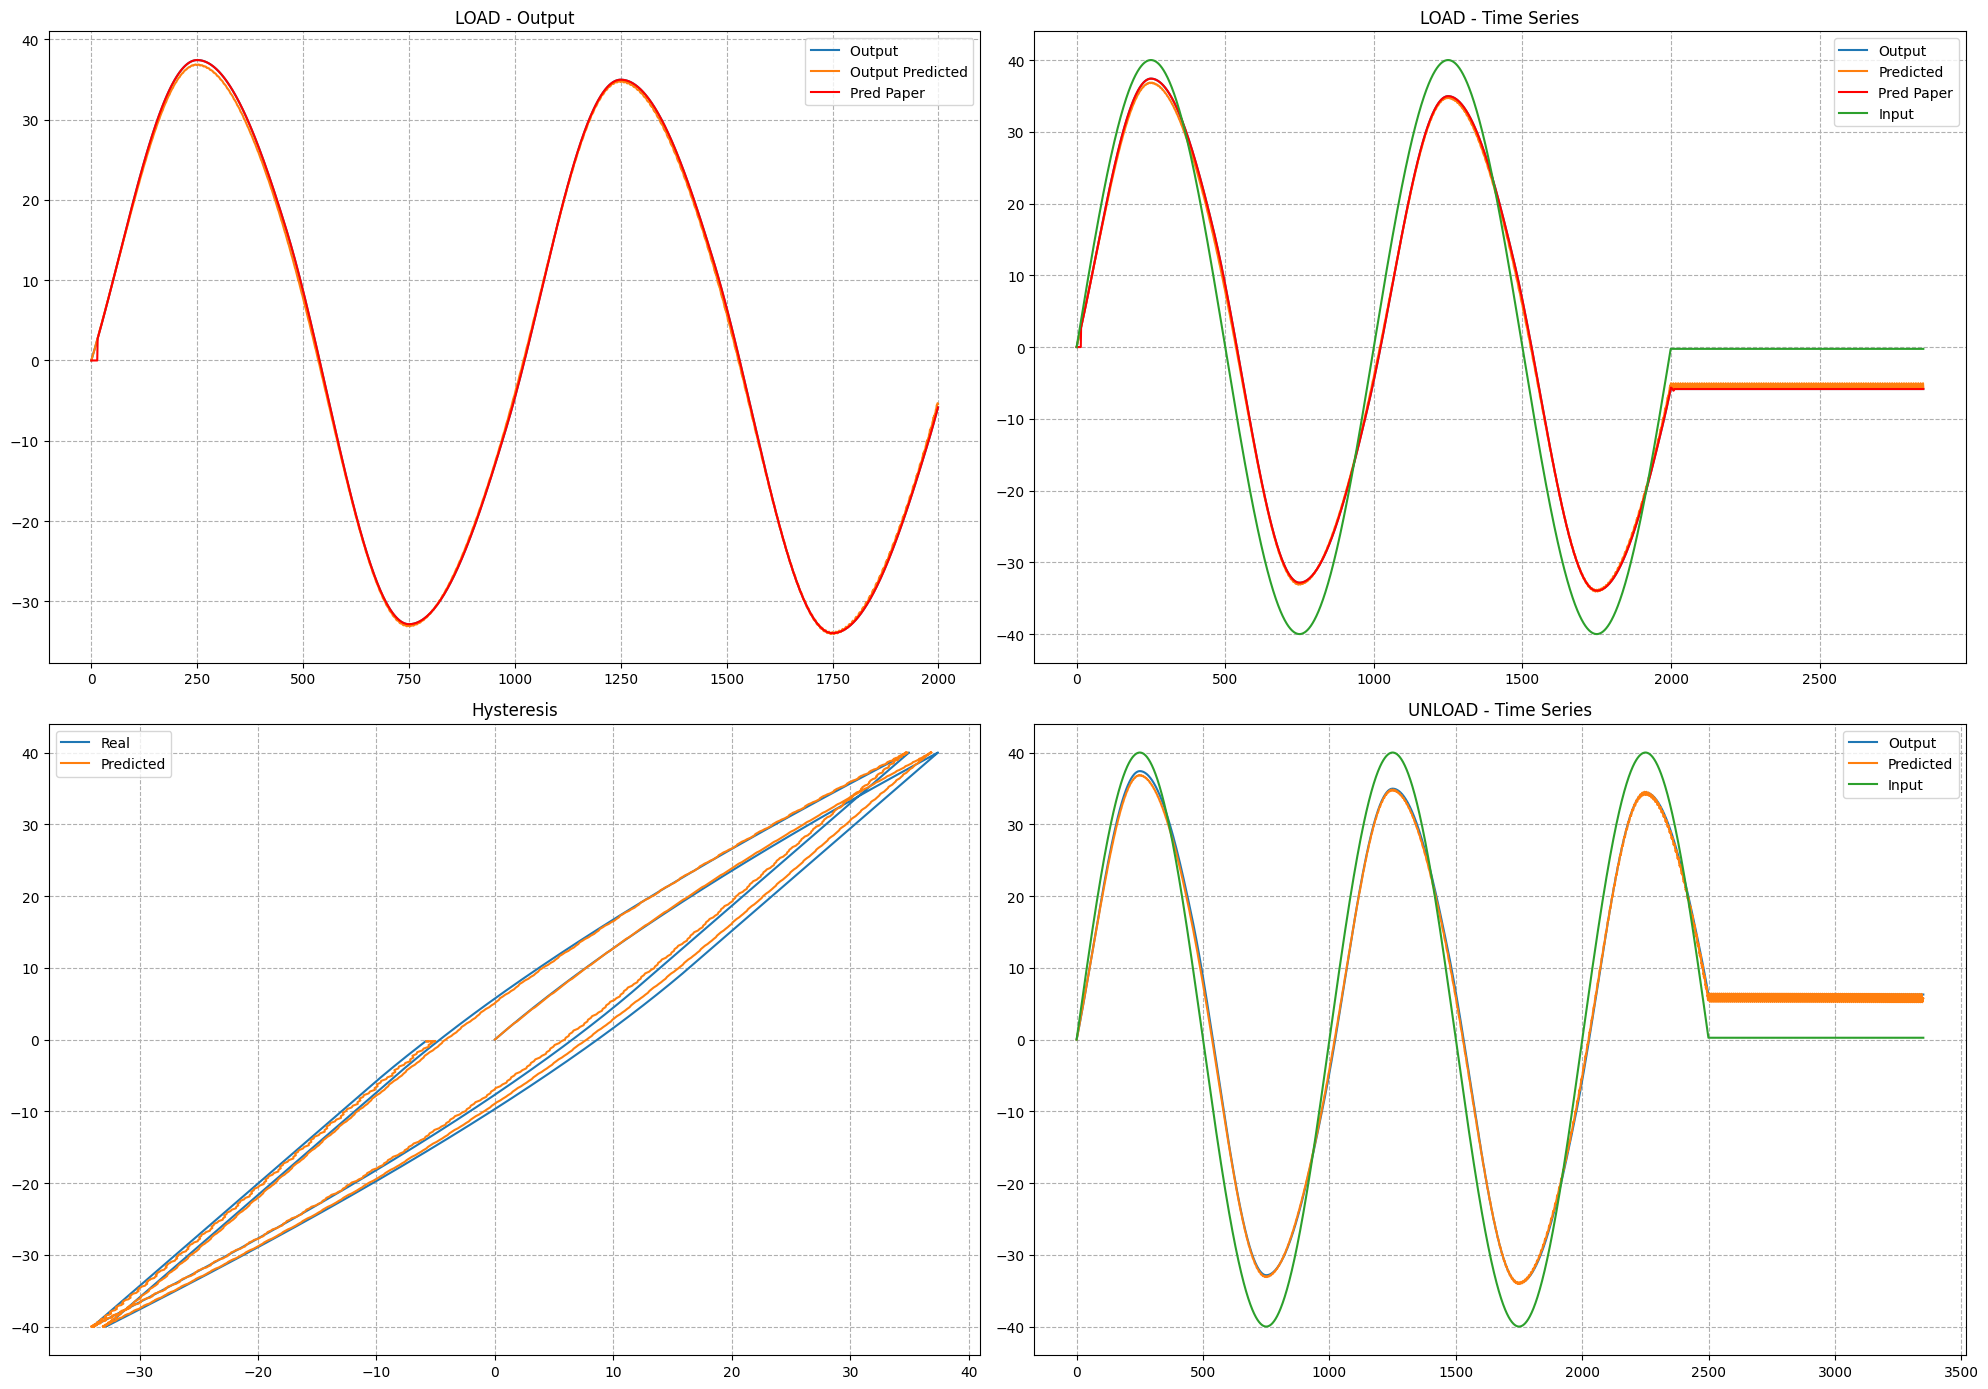

In [ ]:
# Filter requirements.
fs = 1000       # sample rate, Hz
cutoff = 1     # desired cutoff frequency of the filter, Hz ,      slightly higher than actual 1.2 Hz
nyq = 0.5 * fs  # Nyquist Frequency
order = 5      # sin wave can be approx represented as quadratic

t = np.arange(0,101,1/fs)
seed = 93862723
np.random.seed(seed)
dataX = np.random.normal(0, 450, size=(len(t)))
dataX[0:1000] = 0
dataX[-1000:] = 0
u = butter_lowpass_filter(dataX, cutoff, fs, order)
u = u.reshape(-1)
udot = np.diff(u)/np.diff(t)
udot = udot[999:]
u_train = u[1000:]
t = t[1000:]

y_train = simulate(u_train, udot)

u_test = 40*np.sin(2*np.pi*t)
udot = np.diff(u_test)/np.diff(t)
y_test = simulate(u_test, udot)

u_train = np.array([u_train]).T
y_train = np.array([y_train]).T
u_test = np.array([u_test]).T
y_test = np.array([y_test]).T

# ===================== LOAD =====================
split = 2000

u_test_load = u_test[:split]
y_test_load = y_test[:split]

model_filename = "mggp_models_hysteresis\\mggp_0.pkl"

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_load, 
    y_val=y_test_load, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_load) - len(mggp_yd)
y_true_complete = y_test_load[mggp_initial_conditions:]
ypred_mcase1 = mcase1(u_test_load, y_test_load)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1))
y_true_complete = y_true_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]

plt.figure(figsize=(20, 14))

# --- LOAD: saída ---
plt.subplot(2, 2, 1)
plt.plot(y_true_complete, label='Output ')
plt.plot(mggp_pred_complete, label='Output Predicted')
plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.title("LOAD - Output")
plt.grid(linestyle='--')
plt.legend()

# Extensão (load)
y_test_extend = np.repeat(y_test_load[-1], 850).reshape(-1, 1)
y_test_load_ext = np.concatenate([y_test_load, y_test_extend], axis=0)

u_test_extend = np.repeat(u_test_load[-1], 850).reshape(-1, 1)
u_test_load_ext = np.concatenate([u_test_load, u_test_extend], axis=0)

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_load_ext, 
    y_val=y_test_load_ext, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_load_ext) - len(mggp_yd)
y_true_complete = y_test_load_ext[mggp_initial_conditions:]
input_complete = u_test_load_ext[mggp_initial_conditions:]
ypred_mcase1 = mcase1(u_test_load_ext, y_test_load_ext)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1))
y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]


# --- LOAD: histerese ---
plt.subplot(2, 2, 2)
plt.plot(y_true_complete, label='Output')
plt.plot(mggp_pred_complete, label='Predicted')
plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.plot(input_complete, label='Input')
plt.title("LOAD - Time Series")
plt.grid(linestyle='--')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_true_complete, input_complete, label='Real')
plt.plot(mggp_pred_complete, input_complete, label='Predicted')
plt.title("Hysteresis")
plt.grid(linestyle='--')
plt.legend()


# ===================== UNLOAD =====================
split = 2500

u_test_unload = u_test[:split]
y_test_unload = y_test[:split]

# Extensão (unload)
y_test_extend = np.repeat(y_test_unload[-1], 850).reshape(-1, 1)
y_test_unload_ext = np.concatenate([y_test_unload, y_test_extend], axis=0)

u_test_extend = np.repeat(u_test_unload[-1], 850).reshape(-1, 1)
u_test_unload_ext = np.concatenate([u_test_unload, u_test_extend], axis=0)

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_unload_ext, 
    y_val=y_test_unload_ext, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_unload_ext) - len(mggp_yd)
y_true_complete = y_test_unload_ext[mggp_initial_conditions:]
input_complete = u_test_unload_ext[mggp_initial_conditions:]

min_length = min(len(y_true_complete), len(mggp_pred))
y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]

# --- UNLOAD: time series ---
plt.subplot(2, 2, 4)
plt.plot(y_true_complete, label='Output')
plt.plot(mggp_pred_complete, label='Predicted')
plt.plot(input_complete, label='Input')
plt.title("UNLOAD - Time Series")
plt.grid(linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()


# Train Piezoelectric Micromanipulator Benchmark

In [2]:
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)
data

,1,2,3,4,5,6
0,0.00000,39.882983,6.646888,4.455033,21.63725,6.646888
1,0.00005,42.248096,6.840738,4.648882,21.63730,6.840738
2,0.00010,44.872607,6.993324,4.801468,21.63735,6.993324
3,0.00015,46.612109,7.103292,4.911436,21.63740,7.103292
4,0.00020,48.061694,7.169665,4.977810,21.63745,7.169665
...,...,...,...,...,...,...
199996,9.99980,28.545703,5.498415,3.306559,31.63705,5.498415
199997,9.99985,31.566943,5.836699,3.644843,31.63710,5.836699
199998,9.99990,34.527148,6.142631,3.950775,31.63715,6.142631
199999,9.99995,37.197437,6.413495,4.221640,31.63720,6.413495


In [ ]:
split = 250
fontsize = 12
sinal_in = 3
sinal_out = 2
time = data[1][:split]
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(data[sinal_out][:split], label='Output')
plt.plot(data[sinal_in][:split], label='Input')
plt.grid(linestyle="--")
plt.xlabel("Time", fontsize=fontsize)
plt.ylabel("V", fontsize=fontsize)
plt.legend()

plt.subplot(1, 2, 2)
# plt.figure(figsize=(16, 8))
plt.title("hysteresis demonstration")
plt.plot(data[sinal_in][:split], data[sinal_out][:split])
plt.grid(linestyle="--")
plt.xlabel("Input", fontsize=fontsize)
plt.ylabel("Output", fontsize=fontsize)
plt.show()

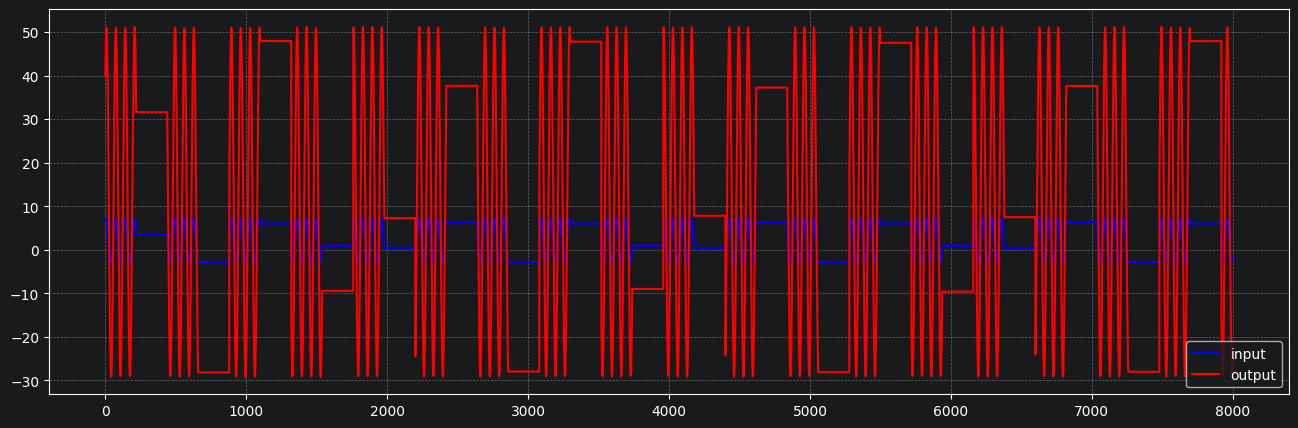

In [2]:
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)

split = 220
sinal_in = 3
sinal_out = 2
time = data[1][:split]

output = data[sinal_out][:split].values.reshape(-1, 1)
input = data[sinal_in][:split].values.reshape(-1, 1)


output_extend = np.repeat(output[-1], split).reshape(-1, 1)
input_extend = np.repeat(input[-1], split).reshape(-1, 1)

output = np.concatenate([output, output_extend], axis=0)
input = np.concatenate([input, input_extend], axis=0)
# split += 20
# split += 20
for i in range(1, 40, 2):
    
    output_step = data[sinal_out][split*i:split*(i+1)].values.reshape(-1, 1)
    input_step = data[sinal_in][split*i:split*(i+1)].values.reshape(-1, 1)

    output_extend = np.repeat(output_step[-1], split).reshape(-1, 1)
    input_extend = np.repeat(input_step[-1], split).reshape(-1, 1)

    output = np.concatenate([output, output_step, output_extend], axis=0)
    input = np.concatenate([input, input_step, input_extend], axis=0)

u_train = input
y_train = output
plt.figure(figsize=(16, 5))
plt.plot(input[:8000], color='b', label='input')
plt.plot(output[:8000], color='r', label='output')
plt.grid(linestyle="--")
plt.legend()
plt.show()

# shottings = 20
# split = output.shape[0]//shottings
# for i in range(shottings):
    
#     output_step = output[split*i:split*(i+1)]
#     input_step = input[split*i:split*(i+1)]

#     plt.figure(figsize=(14, 5))
#     plt.plot(input_step, color='b')
#     plt.plot(output_step, color='r')
#     plt.show()

In [3]:

# y_train = data[2].values.reshape(-1, 1)
# u_train = data[3].values.reshape(-1, 1)
mggp = MGGP(
            inputs=u_train,
            outputs=y_train,
            validation=(u_train, y_train),
            nDelays=1,
            generations=1000,
            populationSize=500,
            evaluationMode="MSE",
            k=100,
            froe_mode=True,
            evaluationType='MShooting',
            evaluationTypeTest="FreeRun",
            nTerms=15,
            maxHeight=3,
            mutationRate=0.2,
            crossoverRate=0.8,
            pruning_probability=0.5,
            pruning_tolerance= 1e-4, 
            elitePercentage=10,
            filename = "mggp_models_hysteresis_piezoeletric/mggp_26.pkl",
            mode="NARX",
            operators=['mul', 'sign', 'subtraction']
            )

# loaded_model = mggp.load_model("mggp_models_hysteresis_piezoeletric/mggp_22.pkl")
mggp.run()

Evaluating Population: 100%|██████████| 434/434 [00:06<00:00, 65.70it/s]


952	434  	0.158033	inf	inf


Evaluating Population: 100%|██████████| 445/445 [00:05<00:00, 76.53it/s] 


953	445  	0.158033	inf	inf


Evaluating Population: 100%|██████████| 442/442 [00:04<00:00, 90.24it/s] 


...

998	439  	0.158033	inf	inf


Evaluating Population: 100%|██████████| 436/436 [00:08<00:00, 51.22it/s]


999	436  	0.158033	inf	inf


Evaluating Population: 100%|██████████| 438/438 [00:08<00:00, 54.72it/s] 


1000	438  	0.158033	inf	inf
0.00000e+00 * 
2.02985e-01 * sign(u1[k] - u1[k-1]) * sign(u1[k] - u1[k-1]) * u1[k] +
2.70752e-01 * u1[k] * u1[k] * sign(u1[k] - u1[k-1]) +
1.00000e+00 * y1[k-1] +
-2.91556e+00 * (u1[k] - u1[k-1]) * u1[k-1] +
3.17353e-01 * y1[k-1] * (u1[k] - u1[k-1]) +
8.50955e-03 * (u1[k] - u1[k-1]) * y1[k-1] * y1[k-1] +
6.62914e-01 * sign(u1[k-1] - u1[k]) * sign(u1[k] - u1[k-1]) +
-9.82886e-02 * y1[k-1] * sign(u1[k] - u1[k-1]) +
1.96566e-01 * (u1[k] - u1[k-1]) * u1[k] * u1[k-1] +
-2.17844e-02 * u1[k] * u1[k] * u1[k] * sign(u1[k] - u1[k-1]) +
4.99725e-01 * u1[k] * sign(u1[k] - u1[k-1]) +
-1.04157e-01 * (u1[k] - u1[k-1]) * u1[k-1] * y1[k-1] +
-9.08256e-01 * (u1[k] - u1[k-1]) * (u1[k] - u1[k-1]) +
-4.45445e+00 * sign(u1[k] - u1[k-1]) +
1.70672e+01 * (u1[k] - u1[k-1]) +
MSE in validation dataset 2: 0.270431
Executed in: 5288.965 seg


## Load and Evaluate Model

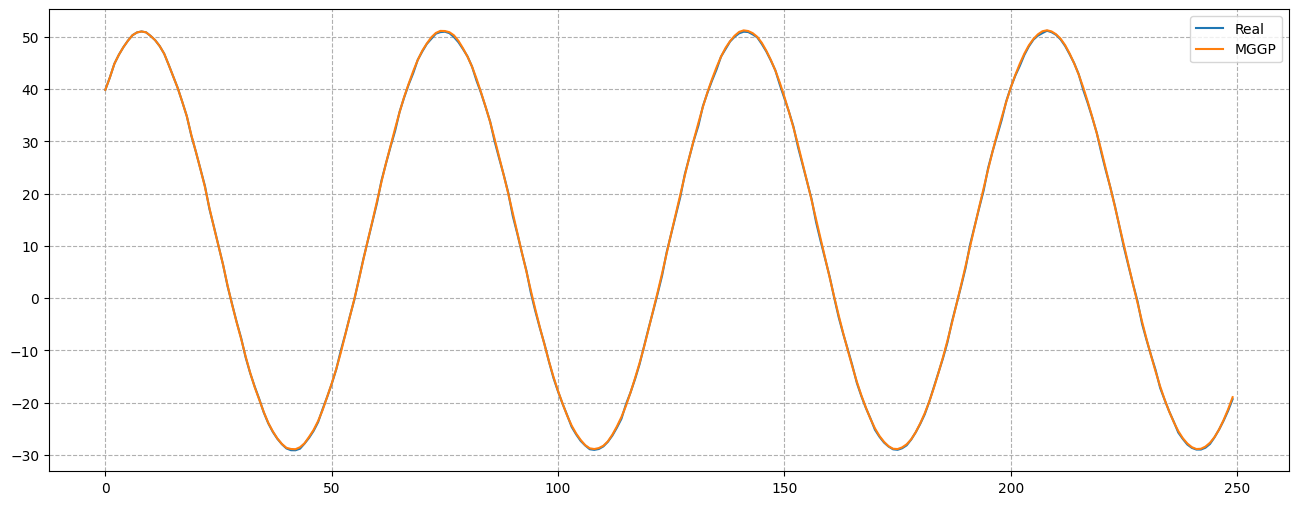

In [26]:
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)

split = 250
sinal_in = 3
sinal_out = 2
time = data[1][:split]

output = data[sinal_out][:split]
input = data[sinal_in][:split]

input = input.values.reshape(-1, 1)
output = output.values.reshape(-1, 1)

model_filename = "mggp_models_hysteresis_piezoeletric\mggp_0.pkl"
# model_filename = "mggp_models_hysteresis/mggp_0.pkl"
mggp_pred, mggp_yd = mggp_predict(X_val=input, 
                                  y_val=output, 
                                  save_model=model_filename)

            
mggp_initial_conditions = len(output) - len(mggp_yd)
y_true_complete = output[mggp_initial_conditions:]
                     
min_length = min(len(y_true_complete), len(mggp_pred))
y_true_complete = y_true_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]

plt.figure(figsize=(16, 6))
plt.plot(y_true_complete, label='Real')
plt.plot(mggp_pred_complete, label='MGGP')
plt.grid(linestyle='--')
plt.legend()
plt.show()

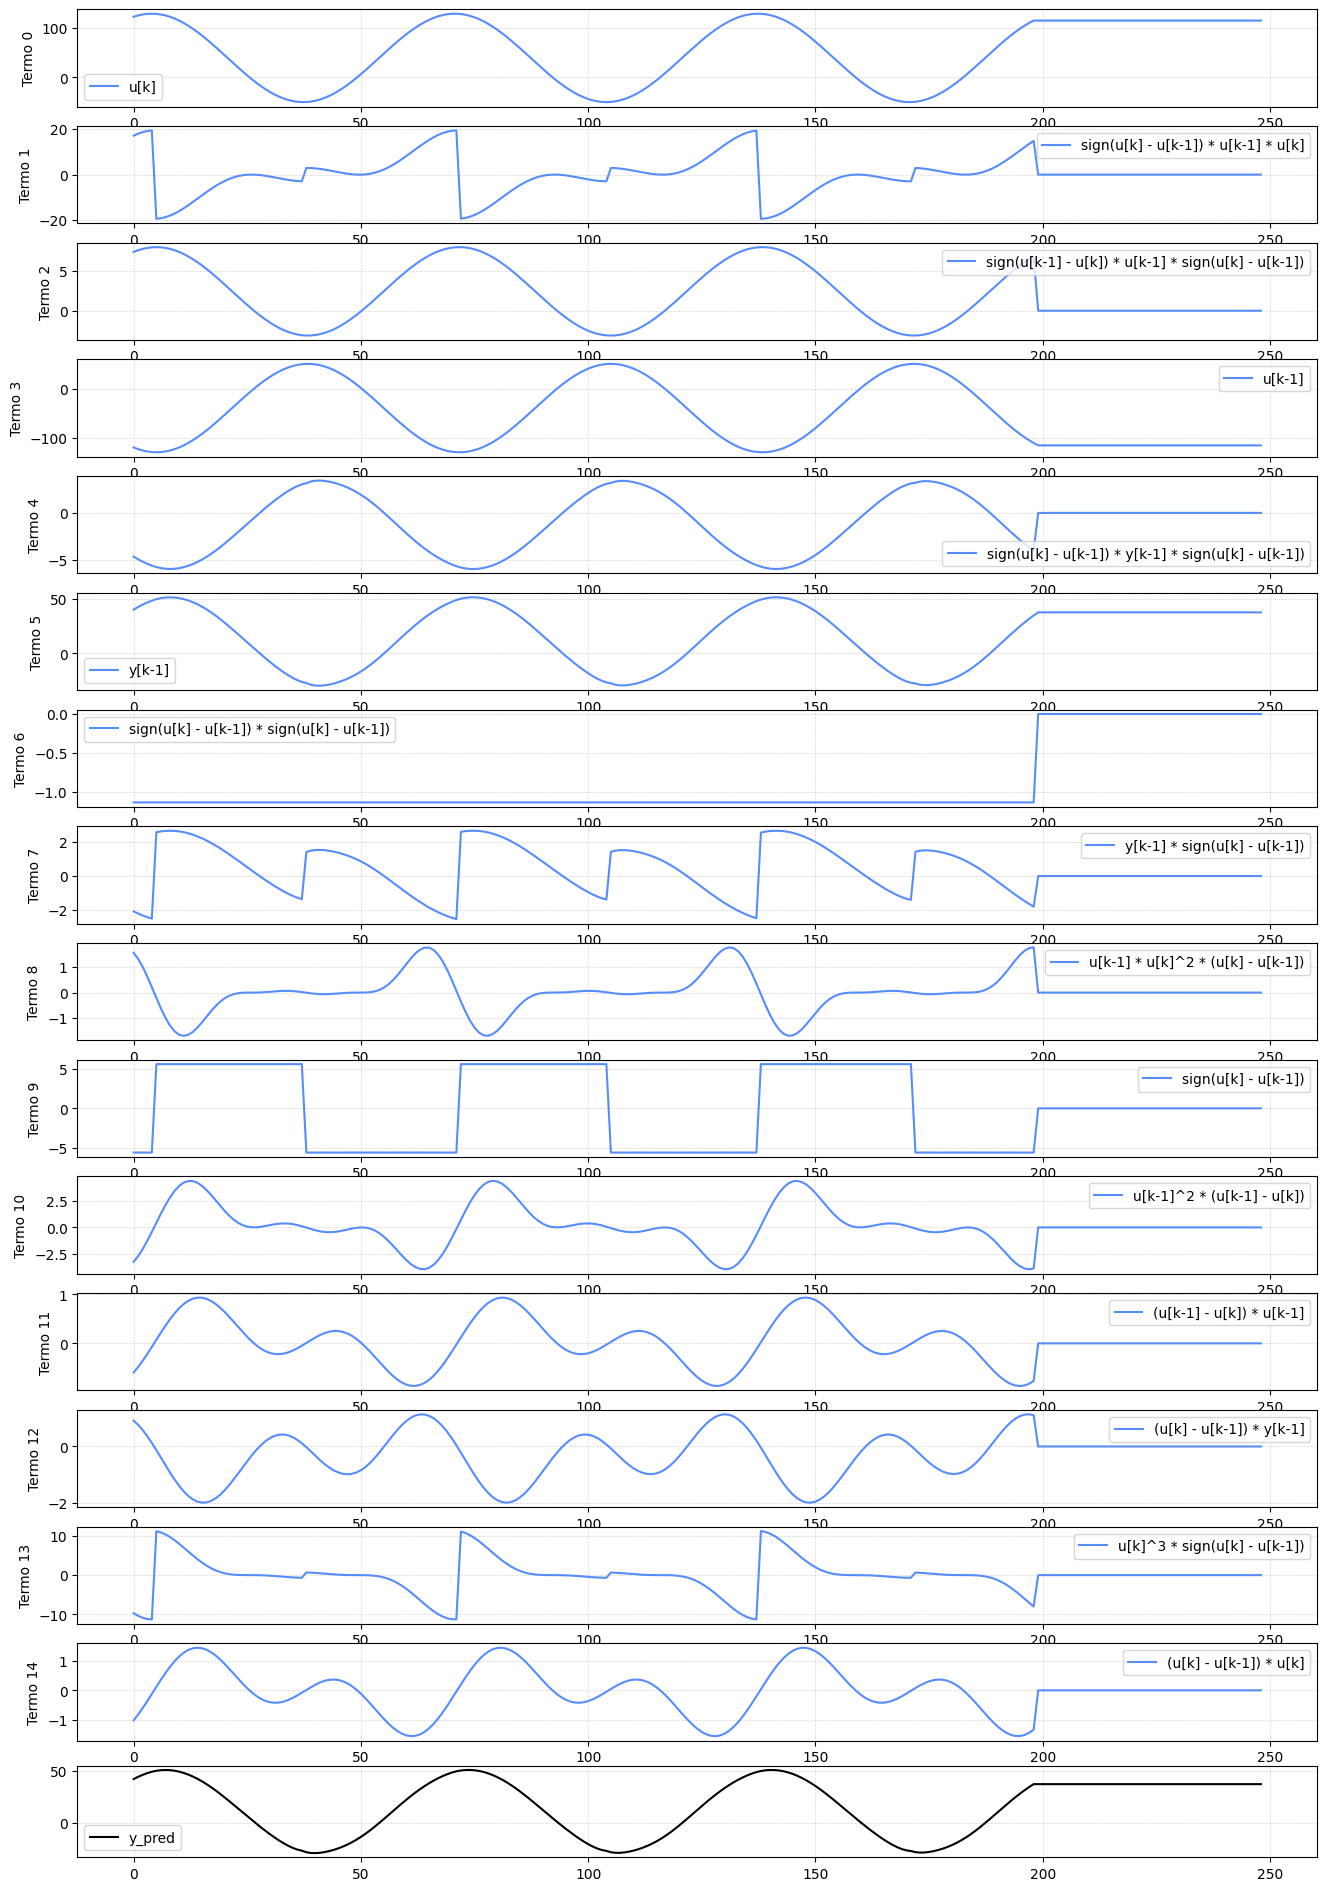

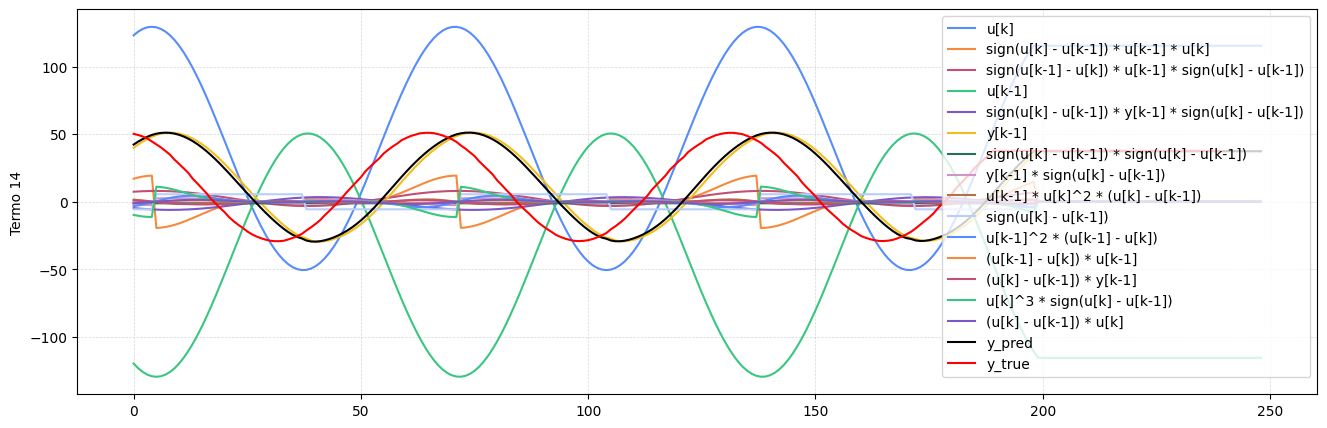

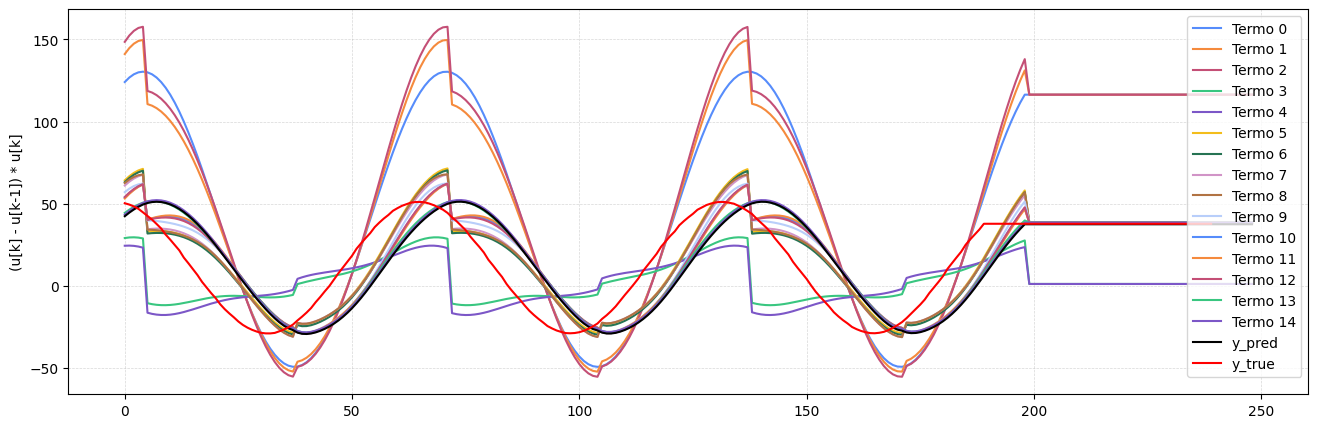

In [9]:
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)

split = 200
sinal_in = 3
sinal_out = 2
time = data[1][:split]

output = data[sinal_out][:split]
input = data[sinal_in][:split]

input = input.values.reshape(-1, 1)
output = output.values.reshape(-1, 1)

output_extend = np.repeat(output[-1], 50).reshape(-1, 1)
output = np.concatenate([output, output_extend], axis=0)

input_extend = np.repeat(input[-1], 50).reshape(-1, 1)
input = np.concatenate([input, input_extend], axis=0)


y_pred, terms = mcase24_free_run_terms(input, output)
term_strings = [
    "u[k]",
    "sign(u[k] - u[k-1]) * u[k-1] * u[k]",
    "sign(u[k-1] - u[k]) * u[k-1] * sign(u[k] - u[k-1])",
    "u[k-1]",
    "sign(u[k] - u[k-1]) * y[k-1] * sign(u[k] - u[k-1])",
    "y[k-1]",
    "sign(u[k] - u[k-1]) * sign(u[k] - u[k-1])",
    "y[k-1] * sign(u[k] - u[k-1])",
    "u[k-1] * u[k]^2 * (u[k] - u[k-1])",
    "sign(u[k] - u[k-1])",
    "u[k-1]^2 * (u[k-1] - u[k])",
    "(u[k-1] - u[k]) * u[k-1]",
    "(u[k] - u[k-1]) * y[k-1]",
    "u[k]^3 * sign(u[k] - u[k-1])",
    "(u[k] - u[k-1]) * u[k]"
]



plt.figure(figsize=(16, 24))
for i in range(terms.shape[0]):
    plt.subplot(16, 1, i+1)
    plt.plot(terms[i], label=term_strings[i])
    plt.ylabel(f"Termo {i}")
    plt.grid(linestyle='--')
    plt.legend()

plt.subplot(17, 1, 17)
plt.plot(y_pred, label='y_pred', color='k')
plt.grid(linestyle='--')
plt.legend()
plt.show()


plt.figure(figsize=(16, 5))
for i in range(terms.shape[0]):
    # plt.subplot(12, 1, i+1)
    plt.plot(terms[i], label=term_strings[i])
    plt.ylabel(f"Termo {i}")
    # plt.ylabel(term_strings[i])
    plt.grid(linestyle='--')
    plt.legend()

# plt.subplot(12, 1, 12)
plt.plot(y_pred, label='y_pred', color='k')
plt.plot(output[10:], label='y_true', color='r')
plt.grid(linestyle='--')
plt.legend()
plt.show()

all_terms = np.ones(terms[i].shape)
plt.figure(figsize=(16, 5))
for i in range(terms.shape[0]):
    # plt.subplot(12, 1, i+1)
    all_terms += terms[i]
    plt.plot(all_terms, label=f"Termo {i}")
    plt.ylabel(term_strings[i])
    plt.grid(linestyle='--')
    plt.legend()

# plt.subplot(12, 1, 12)
plt.plot(y_pred, label='y_pred', color='k')
plt.plot(output[10:], label='y_true', color='r')
plt.grid(linestyle='--')
plt.legend()
plt.show()


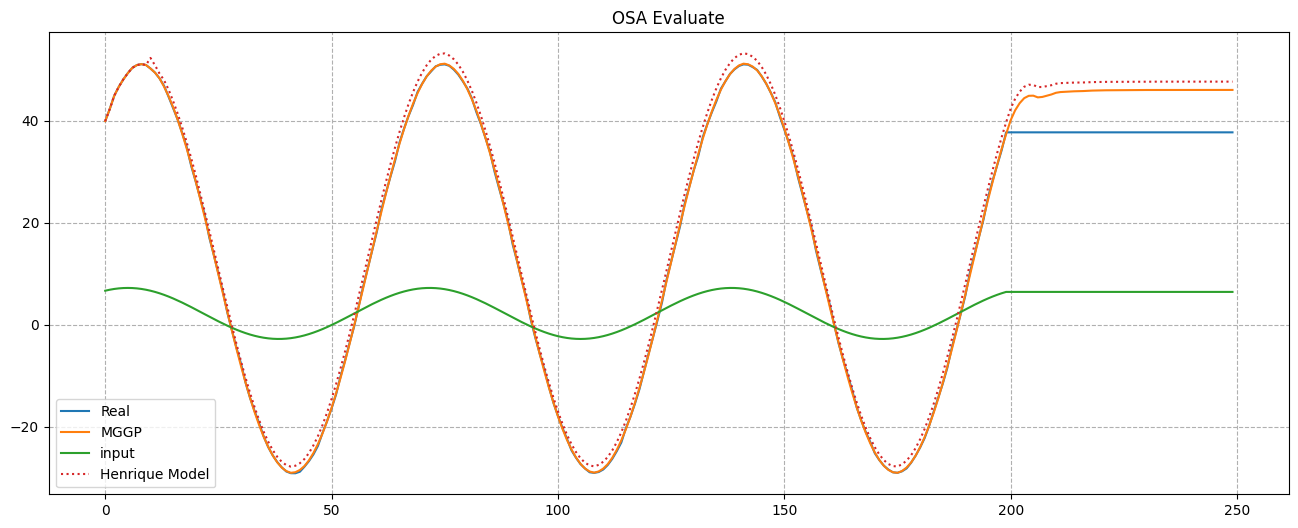

In [20]:
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)

split = 200
sinal_in = 3
sinal_out = 2
time = data[1][:split]

output = data[sinal_out][:split]
input = data[sinal_in][:split]

input = input.values.reshape(-1, 1)
output = output.values.reshape(-1, 1)

output_extend = np.repeat(output[-1], 50).reshape(-1, 1)
output = np.concatenate([output, output_extend], axis=0)

input_extend = np.repeat(input[-1], 50).reshape(-1, 1)
input = np.concatenate([input, input_extend], axis=0)

model_filename = "mggp_models_hysteresis_piezoeletric\mggp_17.pkl"
# model_filename = "mggp_models/hysteresis_model.pkl"
# model_filename = "mggp_models_hysteresis/mggp_0.pkl"
# model_filename = "mggp_models/hysteresis_model.pkl"
mggp_pred, mggp_yd = mggp_predict(X_val=input, 
                                  y_val=output, 
                                #   evaluationTypeTest="OSA",
                                  save_model=model_filename)


ypred_mcase = mcase(input, output)
mggp_initial_conditions = len(output) - len(mggp_yd)
y_true_complete = output[mggp_initial_conditions:]
input_complete = input[mggp_initial_conditions:]
mcase2_complete = ypred_mcase[mggp_initial_conditions:]

min_length = min(len(y_true_complete), len(mggp_pred))

y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]

plt.figure(figsize=(16, 6))
plt.title("OSA Evaluate")
plt.plot(y_true_complete, label='Real')
plt.plot(mggp_pred_complete, label='MGGP')
plt.plot(input_complete, label='input')
plt.plot(mcase2_complete, label='Henrique Model', linestyle=':')
plt.grid(linestyle='--')
plt.legend()
plt.show()

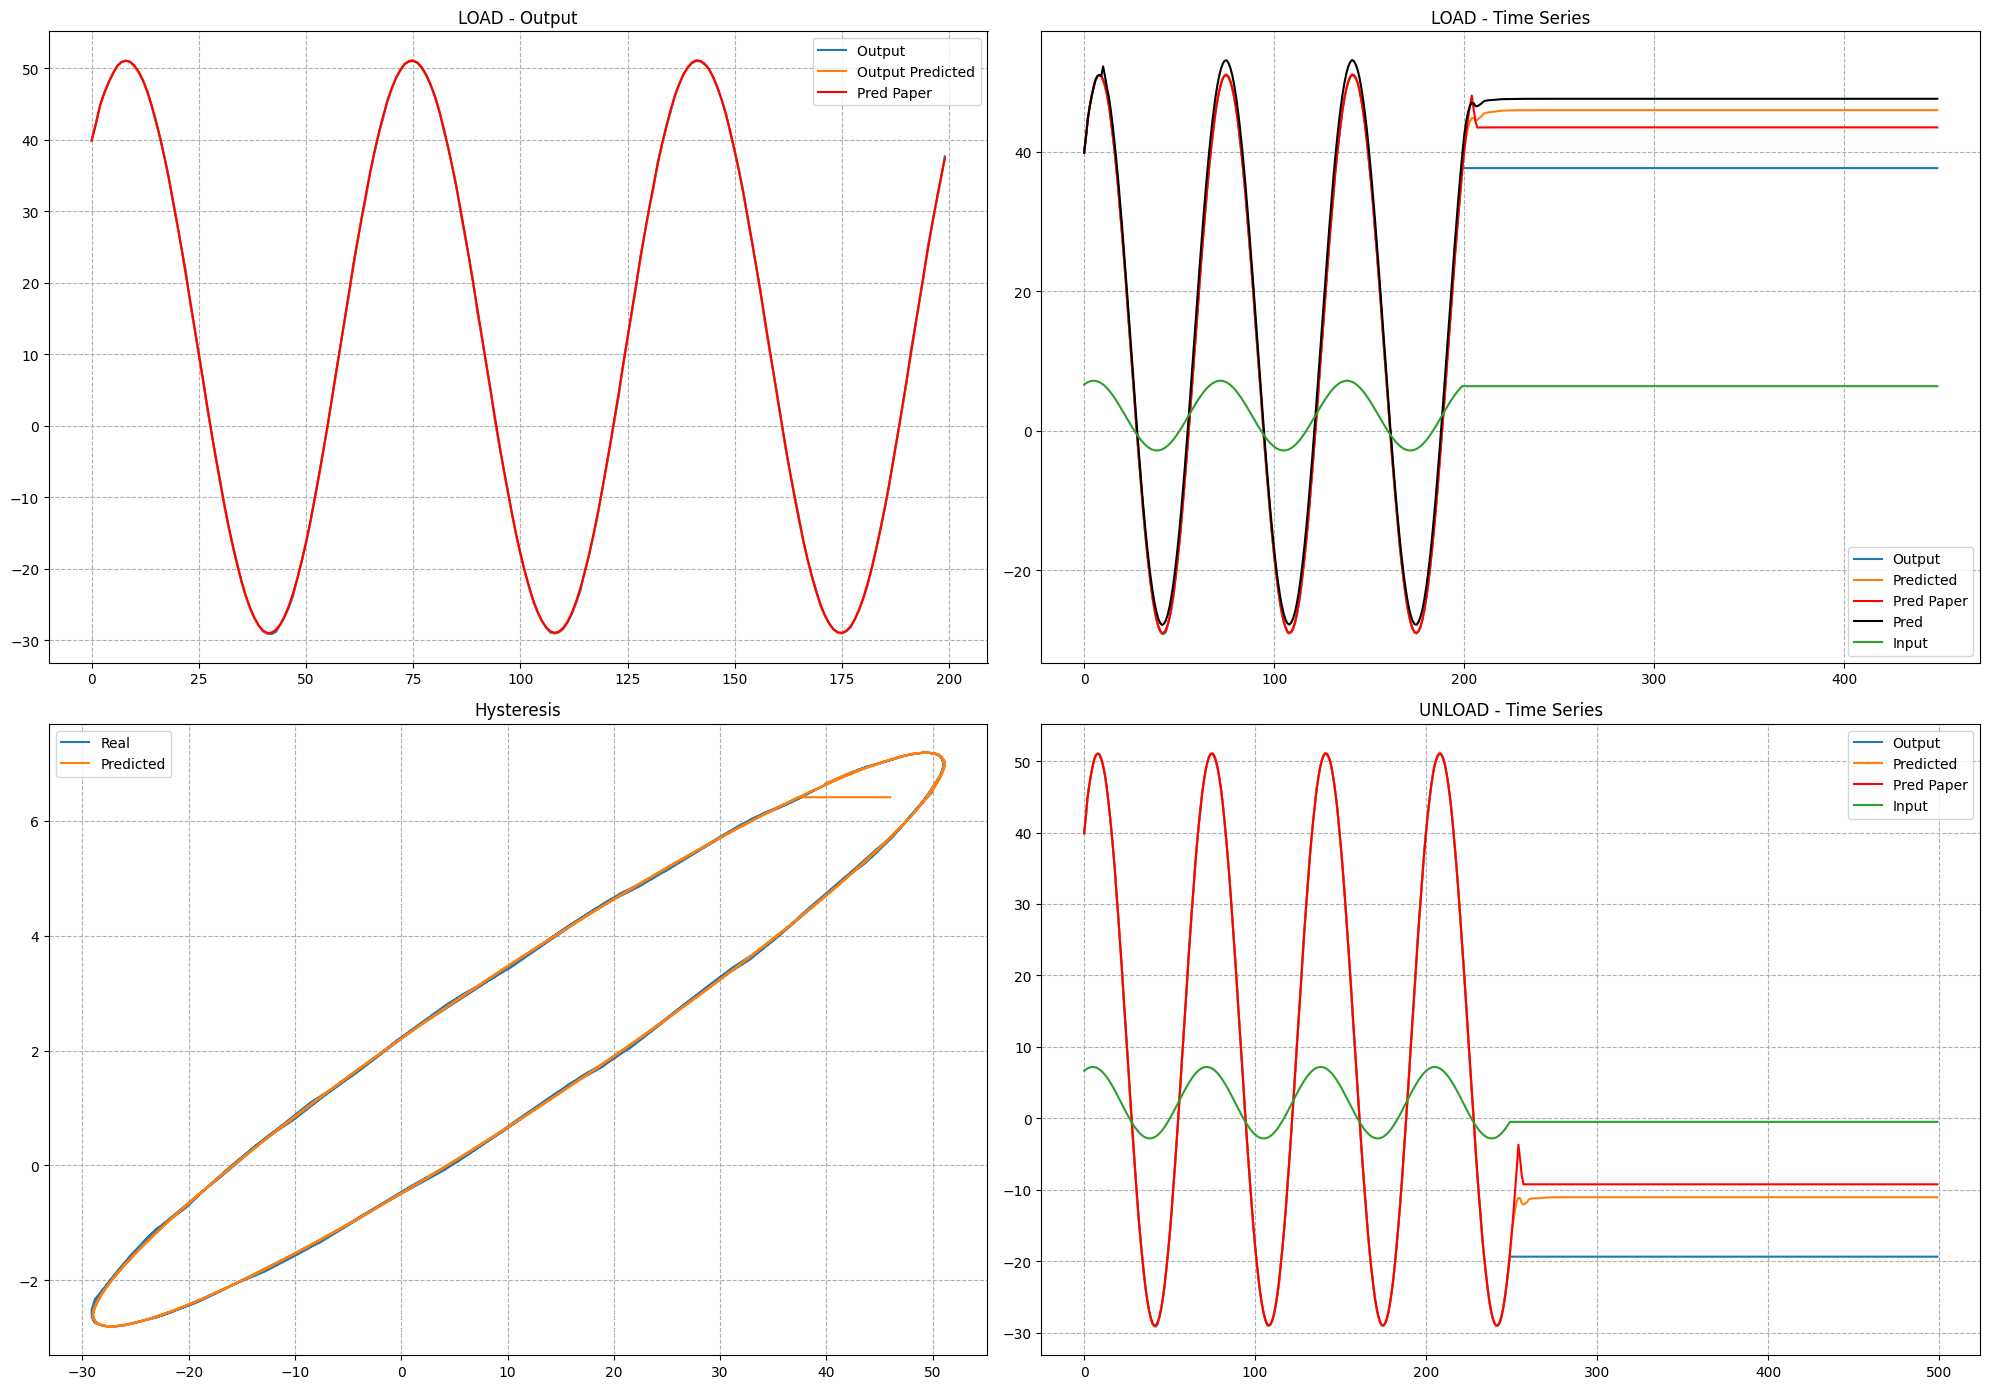

In [42]:
# ===================== LOAD =====================
data = pd.read_csv("hysteresis_data/h50us.csv", header=None)
data.drop(0, axis=1, inplace=True)

sinal_in = 3
sinal_out = 2
time = data[1]

output = data[sinal_out]
input = data[sinal_in]

u_test = input.values.reshape(-1, 1)
y_test = output.values.reshape(-1, 1)

split = 200

u_test_load = u_test[:split]
y_test_load = y_test[:split]

model_filename = "mggp_models_hysteresis_piezoeletric\\mggp_17.pkl"

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_load, 
    y_val=y_test_load, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_load) - len(mggp_yd)
y_true_complete = y_test_load[mggp_initial_conditions:]
ypred_mcase1 = mcase2(u_test_load, y_test_load)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1))
y_true_complete = y_true_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]

plt.figure(figsize=(20, 14))

# --- LOAD: saída ---
plt.subplot(2, 2, 1)
plt.plot(y_true_complete, label='Output ')
plt.plot(mggp_pred_complete, label='Output Predicted')
plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.title("LOAD - Output")
plt.grid(linestyle='--')
plt.legend()

# Extensão (load)
y_test_extend = np.repeat(y_test_load[-1], 250).reshape(-1, 1)
y_test_load_ext = np.concatenate([y_test_load, y_test_extend], axis=0)

u_test_extend = np.repeat(u_test_load[-1], 250).reshape(-1, 1)
u_test_load_ext = np.concatenate([u_test_load, u_test_extend], axis=0)

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_load_ext, 
    y_val=y_test_load_ext, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_load_ext) - len(mggp_yd)
y_true_complete = y_test_load_ext[mggp_initial_conditions:]
input_complete = u_test_load_ext[mggp_initial_conditions:]
ypred_mcase1 = mcase2(u_test_load_ext, y_test_load_ext)
ypred_mcase = mcase(u_test_load_ext, y_test_load_ext)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1), len(ypred_mcase))
y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]
ypred_mcase_complete = ypred_mcase[:min_length]

# --- LOAD: histerese ---
plt.subplot(2, 2, 2)
plt.plot(y_true_complete, label='Output')
plt.plot(mggp_pred_complete, label='Predicted')
plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.plot(ypred_mcase_complete, label='Pred', color='k')
plt.plot(input_complete, label='Input')
plt.title("LOAD - Time Series")
plt.grid(linestyle='--')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(y_true_complete, input_complete, label='Real')
plt.plot(mggp_pred_complete, input_complete, label='Predicted')
plt.title("Hysteresis")
plt.grid(linestyle='--')
plt.legend()


# ===================== UNLOAD =====================
split = 250

u_test_unload = u_test[:split]
y_test_unload = y_test[:split]

# Extensão (unload)
y_test_extend = np.repeat(y_test_unload[-1], 250).reshape(-1, 1)
y_test_unload_ext = np.concatenate([y_test_unload, y_test_extend], axis=0)

u_test_extend = np.repeat(u_test_unload[-1], 250).reshape(-1, 1)
u_test_unload_ext = np.concatenate([u_test_unload, u_test_extend], axis=0)

mggp_pred, mggp_yd = mggp_predict(
    X_val=u_test_unload_ext, 
    y_val=y_test_unload_ext, 
    save_model=model_filename
)

mggp_initial_conditions = len(y_test_unload_ext) - len(mggp_yd)
y_true_complete = y_test_unload_ext[mggp_initial_conditions:]
input_complete = u_test_unload_ext[mggp_initial_conditions:]
ypred_mcase1 = mcase2(u_test_unload_ext, y_test_unload_ext)

min_length = min(len(y_true_complete), len(mggp_pred), len(ypred_mcase1))
y_true_complete = y_true_complete[:min_length]
input_complete = input_complete[:min_length]
mggp_pred_complete = mggp_pred[:min_length]
ypred_mcase1_complete = ypred_mcase1[:min_length]

# --- UNLOAD: time series ---
plt.subplot(2, 2, 4)
plt.plot(y_true_complete, label='Output')
plt.plot(mggp_pred_complete, label='Predicted')
plt.plot(ypred_mcase1_complete, label='Pred Paper', color='r')
plt.plot(input_complete, label='Input')
plt.title("UNLOAD - Time Series")
plt.grid(linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()


# Load MGGP Model

In [ ]:
folder = "Job1_2023_07_28_16_41_10_Mix"
path = f"E:\matlab files\iTire road test data\{folder}\Tire_Features_extraidas_35_25.csv"
u_train, y_train, _, _ = load_data(path, 3, folder)

save_model = "mggp_models_hysteresis_piezoeletric/mggp_17.pkl"
# save_model = "mggp_models/hysteresis_model.pkl"
# save_model = "mggp_models_hysteresis/mggp_1.pkl"
mggp = MGGP(inputs=u_train,
                    outputs=y_train,
                    filename=save_model, 
                    operators=['mul', 'sign', 'subtraction']
                    # kwargs={'operators': ['mul', 'subtraction', 'sign']}
                    )

loaded_model = mggp.load_model()

# print(mggp.simplify_model(loaded_model))
print(loaded_model)

1
q2(y1)
q5(q2(q1(q1(q1(u1)))))
q4(subtraction(q1(u1), q2(u1)))
q3(subtraction(q5(q4(u1)), q1(q2(u1))))
u1
q2(q4(q4(y1)))
sign(q1(u1), q2(q1(q1(u1))))
q5(q1(u1))
u1
y1



In [19]:
soma = 0
for i in [2, 5, 8, 9]: # termos lineares input
# for i in [1, 6, 10]: # linear outputs
# for i in [3, 4, 7]: # phi outputs
    soma += loaded_model.theta[i][0]
soma

4.596323321948148e-14

In [14]:
for i in range(len(loaded_model.theta)):
    print(f'{i} - {loaded_model.theta[i][0]}')

0 - -6.449701883681769e-14
1 - 0.300742221603808
2 - 1.157059550460019
3 - 0.03974769250889043
4 - -0.09372108147028588
5 - 1.0571898587117923
6 - -0.05383488830604312
7 - 0.05397338896144662
8 - -3.271439267907053
9 - 1.0571898587352877
10 - 0.7530926667022311


In [ ]:
1, 2, 4, 5, 6, 

In [9]:
soma = loaded_model.theta[0][0]
# soma = 0
for i in [1, 2, 4, 5, 6]:
    soma += loaded_model.theta[i][0]

soma

2.44050622390821